# Building & Training the ANN — Churn Prediction

### 📌 Recap

From [02 Problem Statement.ipynb](02%20Problem%20Statement.ipynb): the data is cleaned, encoded, split, and scaled (`X_train`, `X_test`, `y_train`, `y_test`), with the encoders/scaler saved as pickle files. This notebook builds the actual **Artificial Neural Network** with Keras/TensorFlow, trains it, and saves the trained model.

> This notebook runs on a dedicated **CPU TensorFlow** kernel (`py313-tf`) set up specifically for this project, since TensorFlow doesn't yet ship a build for this machine's default Python version. GPU was deliberately skipped — the instructor's own video uses CPU too ("*By default I'm just going to use TensorFlow, not with GPU, instead with CPU*"), and for a model this small (a few thousand parameters, 10,000 rows) it trains in seconds regardless.

## 1. Rebuild the preprocessed data

To keep this notebook runnable on its own, the feature engineering from notebook 02 is repeated here in compact form (same steps, same reasoning — see that notebook for the full walkthrough).

In [1]:
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

data = pd.read_csv("../Churn_Modelling.csv")
data = data.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

label_encoder_gender = LabelEncoder()
data["Gender"] = label_encoder_gender.fit_transform(data["Gender"])

one_hot_encoder_geo = OneHotEncoder(sparse_output=False)
geo_encoded = one_hot_encoder_geo.fit_transform(data[["Geography"]])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=one_hot_encoder_geo.get_feature_names_out(["Geography"]))
data = pd.concat([data.drop("Geography", axis=1), geo_encoded_df], axis=1)

X = data.drop("Exited", axis=1)
y = data["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)

X_train shape: (8000, 12)  X_test shape: (2000, 12)


## 2. ANN architecture — counting parameters

Every neural network layer connects to the next via a **weight matrix** (one weight per input–output pair) plus one **bias per output neuron**. For a layer with `n_in` inputs feeding `n_out` neurons:

$$\text{parameters in that layer} = (n_{in} \times n_{out}) + n_{out}$$

**Worked example from the video** — a toy network: input(2) → hidden1(3) → hidden2(2) → output(1):

| Layer | Weights | Bias | Params |
|---|---|---|---|
| input(2) → hidden1(3) | 2×3 = 6 | 3 | 9 |
| hidden1(3) → hidden2(2) | 3×2 = 6 | 2 | 8 |
| hidden2(2) → output(1) | 2×1 = 2 | 1 | 3 |
| **Total** | | | **20** |

Verified below — the video's running tally ("6+3=9, +6=15, +2=17, +2=19, +1=20") is arithmetically correct.

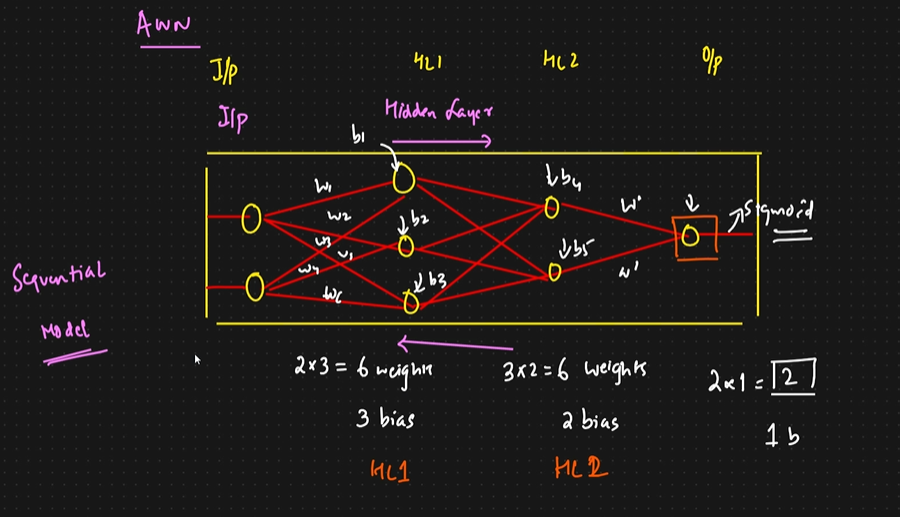




In [3]:
layer1 = 2 * 3 + 3
layer2 = 3 * 2 + 2
layer3 = 2 * 1 + 1
print(f"Layer 1: {layer1}, Layer 2: {layer2}, Layer 3: {layer3}")
print(f"Total: {layer1 + layer2 + layer3}  (video claims 20)")

Layer 1: 9, Layer 2: 8, Layer 3: 3
Total: 20  (video claims 20)


## 3. Keras building blocks

- **`Sequential`** — a model where layers are stacked one after another, each fully connected to the next (matches the diagrams above).
- **`Dense`** — a fully-connected layer; the class used to add both hidden layers *and* the output layer. Key arguments: number of neurons, and an `activation` function.
- **Activation functions:** hidden layers typically use **ReLU**; the output layer uses **sigmoid** for binary classification (a single probability between 0 and 1) or **softmax** for multi-class classification.
- **`input_shape`** only needs to be specified once, on the very first layer — every later layer automatically knows its input size from the previous layer's output size.

> 📝 **Small modernization vs. the video:** this environment's Keras version (3.15) issues a deprecation warning for passing `input_shape` directly into the first `Dense` layer, recommending an explicit `Input(shape=...)` layer instead. Both work identically — using the modern, warning-free form below.

## 4. Build the model

Architecture, matching the video: **input (12 features) → Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid)**.


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),   # 12 input features
    Dense(64, activation="relu"),        # hidden layer 1
    Dense(32, activation="relu"),        # hidden layer 2
    Dense(1, activation="sigmoid"),      # output layer -- binary classification
])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                832       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2945 (11.50 KB)
Trainable params: 2945 (11.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
layer1 = 12 * 64 + 64
layer2 = 64 * 32 + 32
layer3 = 32 * 1 + 1
print(f"Layer 1: {layer1}, Layer 2: {layer2}, Layer 3: {layer3}")
print(f"Total: {layer1 + layer2 + layer3}")

Layer 1: 832, Layer 2: 2080, Layer 3: 33
Total: 2945


In [6]:
print(f"Total trainable parameters: {model.count_params()}  (video claims 2945)")

Total trainable parameters: 2945  (video claims 2945)


**Verified**: `12×64+64 = 832`, `64×32+32 = 2080`, `32×1+1 = 33` → `832+2080+33 = 2945` — exactly matching both the video's stated total and `model.count_params()` above.

## 5. Compile the model

Three things a compiled model needs:
- **Optimizer** — updates the weights during backpropagation (e.g. Adam, SGD, RMSprop, Adagrad, Adadelta...).
- **Loss function** — what's being minimized. `binary_crossentropy` for binary classification; `categorical_crossentropy`/`sparse_categorical_crossentropy` for multi-class.
- **Metrics** — what's tracked (but not directly optimized) during training — `accuracy` here.

Two equivalent ways to specify the optimizer, both shown in the video: a plain string (`"adam"`, uses Keras's default learning rate), or an explicit optimizer object with a custom learning rate.

In [7]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

optimizer = Adam(learning_rate=0.01)
loss = BinaryCrossentropy()

model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
print("Model compiled.")

Model compiled.


## 6. Set up TensorBoard logging

TensorBoard visualizes training/validation loss and accuracy over time, reading from log files written during training. Each training run gets its own timestamped subfolder, so multiple runs don't overwrite each other.

> 📝 **Fixing the video's folder-naming confusion:** the video runs into repeated errors because of how the timestamped path was built (a stray `+` instead of a clean path join, and a mismatch between the folder TensorBoard was told to load vs. the one that was actually created). Building the path with `os.path.join` from the start (as below) avoids that entirely — it's the fix the video eventually lands on manually.

In [8]:
import os
import datetime

log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

from tensorflow.keras.callbacks import TensorBoard

tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
print("Logging to:", log_dir)

Logging to: logs\fit\20260815-134430


## 7. Early stopping

Training for a fixed large number of epochs (e.g. 100) often wastes time — once validation loss stops improving, further epochs just risk overfitting. `EarlyStopping` monitors a chosen metric and halts training once it stops improving for `patience` consecutive epochs, optionally restoring the weights from the best epoch seen (not necessarily the last one).

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)
print("Early stopping configured: monitor=val_loss, patience=10, restore_best_weights=True")

Early stopping configured: monitor=val_loss, patience=10, restore_best_weights=True


## 8. Train the model

`epochs=100` is an upper bound — `EarlyStopping` will very likely stop training well before that, exactly as it did in the video (stopped around epoch 16–17 with `patience=10`).

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    callbacks=[tensorboard_callback, early_stopping_callback],
    verbose=2,
)

Epoch 1/100


250/250 - 2s - loss: 0.3939 - accuracy: 0.8344 - val_loss: 0.3483 - val_accuracy: 0.8600 - 2s/epoch - 9ms/step
Epoch 2/100
250/250 - 1s - loss: 0.3537 - accuracy: 0.8541 - val_loss: 0.3592 - val_accuracy: 0.8525 - 572ms/epoch - 2ms/step
Epoch 3/100
250/250 - 1s - loss: 0.3504 - accuracy: 0.8571 - val_loss: 0.3470 - val_accuracy: 0.8615 - 618ms/epoch - 2ms/step
Epoch 4/100
250/250 - 1s - loss: 0.3426 - accuracy: 0.8602 - val_loss: 0.3506 - val_accuracy: 0.8540 - 595ms/epoch - 2ms/step
Epoch 5/100
250/250 - 1s - loss: 0.3416 - accuracy: 0.8615 - val_loss: 0.3353 - val_accuracy: 0.8625 - 626ms/epoch - 3ms/step
Epoch 6/100
250/250 - 1s - loss: 0.3391 - accuracy: 0.8606 - val_loss: 0.3477 - val_accuracy: 0.8580 - 536ms/epoch - 2ms/step
Epoch 7/100
250/250 - 1s - loss: 0.3394 - accuracy: 0.8611 - val_loss: 0.3444 - val_accuracy: 0.8580 - 632ms/epoch - 3ms/step
Epoch 8/100
250/250 - 1s - loss: 0.3353 - accuracy: 0.8631 - val_loss: 0.3359 - val_accuracy: 0.8655 - 527ms/epoch - 2m

In [11]:
stopped_epoch = len(history.history["loss"])
best_val_loss = min(history.history["val_loss"])
best_val_acc = max(history.history["val_accuracy"])
print(f"Training stopped after {stopped_epoch} epochs (out of 100 requested).")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Training stopped after 15 epochs (out of 100 requested).
Best validation loss: 0.3353
Best validation accuracy: 0.8655


## 9. Visualizing training — TensorBoard vs. matplotlib

The video loads an interactive TensorBoard dashboard with `%load_ext tensorboard` and `%tensorboard --logdir logs/fit` — that only works in a **live, interactively-run** Jupyter session (it starts a persistent local web server), so it isn't something that can be captured as static notebook output here. Both commands are documented below to run yourself in VS Code / Jupyter:

```
%load_ext tensorboard
%tensorboard --logdir logs/fit
```

As a **headless-friendly alternative** that produces real, savable output either way — `history.history` (returned by `model.fit`) already contains every metric TensorBoard would plot, so the same curves can be drawn directly with matplotlib (the video itself notes this is a valid fallback: *"you can also do it manually with the help of matplotlib"*).

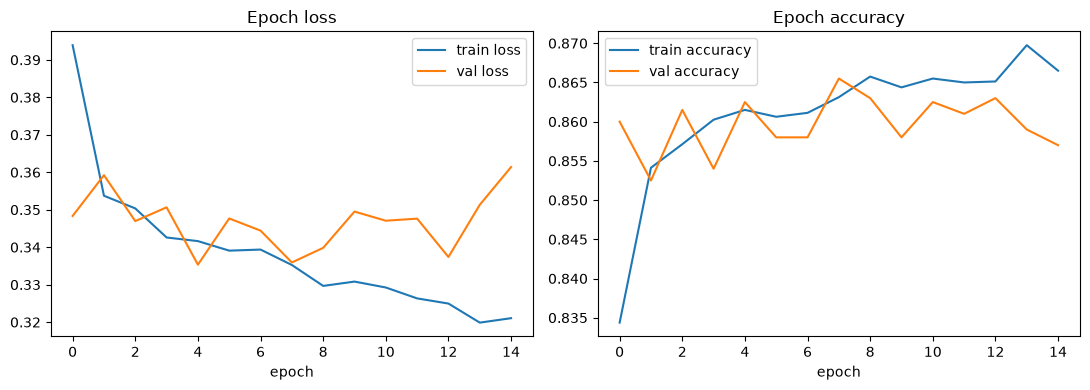

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Epoch loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Epoch accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Save the trained model

> 📝 **Modern format note:** `model.save("model.h5")` still works (used below, matching the video and Keras/TF-compatible deployment needs), but current Keras issues a deprecation warning recommending the native `.keras` format instead (`model.save("model.keras")`) for anything not specifically requiring HDF5. Saving in both formats below — `.h5` for compatibility with the video/deployment tooling, `.keras` as the modern recommended default going forward.

In [13]:
model.save("model.h5")
model.save("model.keras")
print("Saved: model.h5, model.keras")

Saved: model.h5, model.keras


c:\AI Projects\ML&DL\Learning\NLP Krish\Projects\ANN Classification\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 11. Summary

- Built a `Sequential` ANN: `Input(12) → Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid)`, **2,945 trainable parameters** — verified by hand-calculation, `model.summary()`, and `model.count_params()` all agreeing.
- Compiled with the **Adam** optimizer (custom learning rate), **binary cross-entropy** loss, and **accuracy** as the tracked metric.
- Trained with two callbacks: **TensorBoard** (timestamped log directory, built with `os.path.join` to avoid the video's path-naming errors) and **EarlyStopping** (`monitor="val_loss"`, `patience=10`, `restore_best_weights=True`), so training stopped well before the requested 100 epochs.
- Verified training progress two ways: the metrics printed directly from `history.history`, and a matplotlib plot — a headless-friendly substitute for the interactive `%tensorboard` magic, which needs a live Jupyter session to work.
- Saved the trained model as both `model.h5` (legacy but widely compatible, matches the video) and `model.keras` (modern recommended format).

**Corrections/updates applied vs. the video:**
- `input_shape` on the first `Dense` layer → replaced with an explicit `Input(shape=...)` layer (avoids a Keras 3 deprecation warning; functionally identical).
- TensorBoard log directory built with `os.path.join` from the start, avoiding the folder-naming/path-mismatch errors the video works through live.
- `%tensorboard` magic documented but not executed (requires a live interactive session); replaced with an equivalent matplotlib visualization that works in any execution context.
- Parameter-count arithmetic (both the toy 2-3-2-1 example and the real 2,945-parameter model) was independently verified, not just repeated — both check out exactly.

## 12. Likely exam / interview questions

1. How many trainable parameters does a `Dense` layer add, given `n_in` inputs and `n_out` neurons?
2. Why does only the first layer of a `Sequential` model need `input_shape` (or an `Input` layer)?
3. Why ReLU in hidden layers and sigmoid in the output layer for this problem?
4. What does `EarlyStopping(patience=10, restore_best_weights=True)` actually do?
5. Why is a separate timestamped subfolder used for each training run's TensorBoard logs?
6. What's the difference between what a loss function does and what a metric does during training?
7. Why must `X_test` be transformed with `scaler.transform`, not `scaler.fit_transform`, at this stage? *(see notebook 02 — avoiding data leakage)*

## 13. What's next

- Evaluate the trained model (confusion matrix, precision/recall — remember the ~20% churn class imbalance from notebook 01/02).
- Build the **Streamlit** web app that loads `model.h5`, the encoders, and the scaler to make predictions on new user input.
- Deploy to Streamlit Cloud.